### import

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc("font",family='Kai')
plt.rcParams['axes.unicode_minus'] =False
from pyqpanda import *
from sklearn import linear_model
from scipy.integrate import solve_ivp
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget

# Lorenz63系统部分

In [8]:
def lorenz63(x0, sigma, rho, beta, num_steps, dt):
    
    def RK45(x, func, h):
        """四阶龙格-库塔积分器"""
        K1 = func(x)
        K2 = func(x + h/2*K1)
        K3 = func(x + h/2*K2)
        K4 = func(x + h*K3)
        return x + h/6*(K1 + 2*K2 + 2*K3 + K4)
    
    def L63_rhs(x, sigma=10.0, rho=28.0, beta=8/3):
        """定义Lorenz 63微分方程"""
        dx = np.zeros(3)
        dx[0] = sigma * (x[1] - x[0])
        dx[1] = rho*x[0] - x[1] - x[0]*x[2]
        dx[2] = x[0]*x[1] - beta*x[2]
        return dx

    def integrate_lorenz63(x0, num_steps, dt):
        """执行数值积分"""
        trajectory = np.zeros((num_steps, 3))
        trajectory[0] = x0
        for t in range(1, num_steps):
            trajectory[t] = RK45(trajectory[t-1], L63_rhs, dt)
        return trajectory

    def normalize_trajectory(trajectory):
        """将轨迹归一化到[0, 1]范围"""
        # 计算每个坐标轴的极值
        mins = np.min(trajectory, axis=0)
        maxs = np.max(trajectory, axis=0)
        
        # 线性归一化公式：new = (original - min)/(max - min)
        normalized =(trajectory - mins) / (maxs - mins)
        return normalized

    traj = integrate_lorenz63(x0, num_steps, dt)
    traj_normalized = normalize_trajectory(traj)
    return traj_normalized


# Classical Reservoir Computing 部分

In [9]:
'''
class ClassicalReservoirComputing:
    def __init__(self, 
                 n_reservoir=200,
                 sparsity=0.05,
                 spectral_radius=0.95,
                 noise=1e-3,
                 input_scaling=0.5,
                 ridge_alpha=1e-4,
                 input_dim=3):  # 添加输入维度参数
        """
        Classical Reservoir Computing (经典回声状态网络)实现
        
        Args:
            n_reservoir: 储层中神经元数量
            sparsity: 储层连接的稀疏度（0到1之间）
            spectral_radius: 储层权重矩阵的谱半径，影响系统记忆长度
            noise: 训练时添加的噪声大小
            input_scaling: 输入缩放因子
            ridge_alpha: 岭回归正则化参数
            input_dim: 输入维度
        """
        self.n_reservoir = n_reservoir
        self.sparsity = sparsity
        self.spectral_radius = spectral_radius
        self.noise = noise
        self.input_scaling = input_scaling
        self.ridge_alpha = ridge_alpha
        self.input_dim = input_dim
        
        # 随机初始化储层权重
        self.W_reservoir = self._initialize_reservoir()
        
        # 初始化输入权重矩阵 (将输入维度映射到储层维度)
        self.W_in = np.random.rand(n_reservoir, input_dim) * 2 - 1
        
        # 训练后获得的输出权重
        self.W_out = None
        self.intercept = None
        
    def _initialize_reservoir(self):
        """初始化储层权重矩阵"""
        # 创建随机稀疏矩阵
        W = np.random.rand(self.n_reservoir, self.n_reservoir) - 0.5
        # 设置稀疏性
        mask = np.random.rand(self.n_reservoir, self.n_reservoir) < self.sparsity
        W *= mask
        # 计算矩阵的最大特征值
        eigenvalues = np.linalg.eigvals(W)
        max_eigen = np.max(np.abs(eigenvalues))
        # 缩放矩阵使其谱半径为spectral_radius
        W *= self.spectral_radius / max_eigen
        return W
        
    def _update(self, state, input_signal):
        """
        更新储层状态
        
        Args:
            state: 当前储层状态，形状为(n_reservoir,)
            input_signal: 输入信号，形状为(input_dim,)
            
        Returns:
            新的储层状态
        """
        # 使用输入权重矩阵将输入信号映射到储层维度
        input_scaled = np.dot(self.W_in, input_signal) * self.input_scaling
        
        # 非线性激活函数 - 使用tanh
        return np.tanh(np.dot(self.W_reservoir, state) + 
                     input_scaled + 
                     self.noise * (np.random.rand(self.n_reservoir) - 0.5))
    
    def fit(self, X, Y):
        """
        训练储层计算模型
        
        Args:
            X: 输入时间序列，形状为(n_samples, n_features)
            Y: 目标输出，形状为(n_samples, n_outputs)
        """
        n_samples = X.shape[0]
        
        # 初始化储层状态
        state = np.zeros((self.n_reservoir,))
        states_collection = np.zeros((n_samples, self.n_reservoir))
        
        # 收集储层状态
        for i in range(n_samples):
            input_signal = X[i]
            state = self._update(state, input_signal)
            states_collection[i] = state
        
        # 使用岭回归训练输出层
        ridge = Ridge(alpha=self.ridge_alpha)
        ridge.fit(states_collection, Y)
        self.W_out = ridge.coef_
        self.intercept = ridge.intercept_
        
        return self
        
    def predict(self, X):
        """
        使用训练好的模型进行预测
        
        Args:
            X: 输入时间序列，形状为(n_samples, n_features)
            
        Returns:
            预测值，形状为(n_samples, n_outputs)
        """
        n_samples = X.shape[0]
        n_outputs = self.W_out.shape[0]
        predictions = np.zeros((n_samples, n_outputs))
        
        # 初始化状态
        state = np.zeros((self.n_reservoir,))
        
        # 逐步预测
        for i in range(n_samples):
            input_signal = X[i]
            state = self._update(state, input_signal)
            prediction = np.dot(self.W_out, state) + self.intercept
            predictions[i] = prediction
            
        return predictions
    
    def predict_future(self, X_init, steps, feedback=True):
        """
        对未来进行预测
        
        Args:
            X_init: 初始输入状态，形状为(n_features,)
            steps: 需要预测的步数
            feedback: 是否使用预测结果作为下一步的输入
            
        Returns:
            预测序列，形状为(steps, n_outputs)
        """
        n_outputs = self.W_out.shape[0]
        predictions = np.zeros((steps, n_outputs))
        
        # 初始化状态
        state = np.zeros((self.n_reservoir,))
        current_input = X_init
        
        # 逐步预测
        for i in range(steps):
            state = self._update(state, current_input)
            prediction = np.dot(self.W_out, state) + self.intercept
            predictions[i] = prediction
            
            if feedback:
                # 使用预测结果作为下一步的输入（闭环预测）
                current_input = prediction
                
        return predictions
'''

'\nclass ClassicalReservoirComputing:\n    def __init__(self, \n                 n_reservoir=200,\n                 sparsity=0.05,\n                 spectral_radius=0.95,\n                 noise=1e-3,\n                 input_scaling=0.5,\n                 ridge_alpha=1e-4,\n                 input_dim=3):  # 添加输入维度参数\n        """\n        Classical Reservoir Computing (经典回声状态网络)实现\n        \n        Args:\n            n_reservoir: 储层中神经元数量\n            sparsity: 储层连接的稀疏度（0到1之间）\n            spectral_radius: 储层权重矩阵的谱半径，影响系统记忆长度\n            noise: 训练时添加的噪声大小\n            input_scaling: 输入缩放因子\n            ridge_alpha: 岭回归正则化参数\n            input_dim: 输入维度\n        """\n        self.n_reservoir = n_reservoir\n        self.sparsity = sparsity\n        self.spectral_radius = spectral_radius\n        self.noise = noise\n        self.input_scaling = input_scaling\n        self.ridge_alpha = ridge_alpha\n        self.input_dim = input_dim\n        \n        # 随机初始化储层权重\n        self.W_reservoi

# Quantum Reservoir Computing 部分

In [10]:
def create_quantum_circuit(params, traj_norm, beta_gate, n_qubits, n_cbits):
    """创建量子线路"""
    qvm = CPUQVM()
    qvm.init_qvm()
    
    qubits = qvm.qAlloc_many(n_qubits)
    cbits = qvm.cAlloc_many(n_qubits)
    
    def module(Ry):
        circuit = QCircuit()
        Ry_index = 0
        ccc = (len(Ry) + n_qubits - 1) // n_qubits
        for layer in range(ccc):
            for qubit in range(n_qubits):
                if Ry_index < len(Ry):
                    circuit << RY(qubits[qubit], Ry[Ry_index])
                    Ry_index += 1
                    if qubit < n_qubits - 1:
                        circuit << CNOT(qubits[qubit], qubits[qubit+1])
        return circuit
        
    # 构建量子程序
    prog = QProg()
    circuit = QCircuit()
    circuit << module(Ry=params)
    circuit << module(Ry=traj_norm)
    circuit << module(Ry=beta_gate)
    prog << circuit
    
    result = qvm.prob_run_dict(prog, qubits, -1)
    value_list = list(result.values())
    return value_list

def nolinearize(varepsilon, sorted_values, value_list, i):   
    """非线性化处理"""
    if i > 0:
        raw_sorted_values = [0] * len(sorted_values)
        for j in range(len(sorted_values)):
            raw_sorted_values[j] = round(varepsilon * value_list[j] + (1 - varepsilon) * sorted_values[j],10)
    else:
        raw_sorted_values = value_list.copy()
    return raw_sorted_values

def all_probabilities(traj_normalized,varepsilon, n_qubits, n_cbits, seed):

    def update_params():
        params = [0] * (2**n_qubits)
        if i > 0:
            # 使用上一次的sorted_values更新参数
            for j in range(len(sorted_values)):
                params[j] = sorted_values[j]*4*np.pi
        return params

    def create_quantum_circuit():
        """创建并返回量子线路"""
        qvm = CPUQVM()
        qvm.init_qvm()
        
        qubits = qvm.qAlloc_many(n_qubits)
        cbits = qvm.cAlloc_many(n_qubits)
        def module(Ry):
            circuit = QCircuit()
            Ry_index = 0
            ccc = (len(Ry) + n_qubits - 1) // n_qubits
            for layer in range(ccc):
                for qubit in range(n_qubits):
                    if Ry_index < len(Ry):
                        circuit << RY(qubits[qubit], Ry[Ry_index])
                        Ry_index += 1
                        if qubit < n_qubits - 1:
                            circuit << CNOT(qubits[qubit], qubits[qubit+1])
            return circuit
        # 构建量子程序
        prog = QProg()
        circuit = QCircuit()
        circuit << module(Ry=params)
        circuit << module(Ry=traj_norm)
        circuit << module(Ry=beta_gate)
        prog << circuit
        
        result = qvm.prob_run_dict(prog, qubits, -1)
        value_list = list(result.values())
        return value_list

    def nolinearize():
        """非线性化处理"""
        if i > 0:
            raw_sorted_values = [0] * len(sorted_values)
            for j in range(len(sorted_values)):
                raw_sorted_values[j] = round(varepsilon * value_list[j] + (1 - varepsilon) * sorted_values[j],10)
        else:
            raw_sorted_values = value_list.copy()
        return raw_sorted_values

    quantum_outputs = [[0]*(2**n_qubits)]
    for i in range(len(traj_normalized)):
        params = update_params()
        traj_norm = 4*np.pi*traj_normalized[i]
        np.random.seed (seed) 
        beta_gate = np.random.uniform (0,2*np.pi,n_qubits)
        value_list = create_quantum_circuit()
        sorted_values = nolinearize()
        quantum_outputs.append(sorted_values)
    return quantum_outputs, n_qubits, n_cbits


# 训练模型部分

In [11]:
def train_ridge_model(washout,nstop_train, alpha, loading_dataX, loading_datay):
    """训练模型"""
    # 准备训练数据
    X_train = loading_dataX[washout:nstop_train]
    y_train = loading_datay[washout:nstop_train]
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    # 训练模型
    ridge = Ridge(alpha)
    ridge.fit(X_train, y_train)
    return ridge, washout, nstop_train

def predict_next_state(method, loading_dataX, loading_datay):
    predictions = []
    for i in range(len(loading_datay)):  
        features = loading_dataX[i]  # 使用已有的量子输出
        all_state_pred = method.predict([features])  # 使用传入的method对象
        predictions.append(all_state_pred[0])
    predictions = np.array(predictions)
    return predictions


# 可视化模块

In [12]:
def plot_normalized_traj(traj_normalized, title="Normalized Trajectory"):
    """
    绘制归一化后的轨迹，根据数据维度自动选择 1D、2D 或 3D 绘图。

    :param traj_normalized: 归一化后的轨迹数据，为 numpy 数组
    :param title: 图的标题
    """
    dim = traj_normalized.shape[1]  # 获取数据的维度

    if dim == 1:
        # 1D 绘图
        fig = plt.figure(figsize=(10, 6))
        plt.plot(traj_normalized[:, 0], lw=1)
        plt.xlabel("Index")
        plt.ylabel("Normalized Value")
        plt.title(title)
    elif dim == 2:
        # 2D 绘图
        fig = plt.figure(figsize=(10, 6))
        plt.plot(traj_normalized[:, 0], traj_normalized[:, 1], lw=1)
        plt.xlim([0, 1])
        plt.ylim([0, 1])
        plt.xlabel("Normalized X")
        plt.ylabel("Normalized Y")
        plt.title(title)
    elif dim == 3:
        # 3D 绘图
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(traj_normalized[:, 0], traj_normalized[:, 1], traj_normalized[:, 2], lw=1)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_zlim([0, 1])
        ax.set_xlabel("Normalized X")
        ax.set_ylabel("Normalized Y")
        ax.set_zlabel("Normalized Z")
        plt.title(title)
    else:
        print(f"不支持绘制 {dim} 维的轨迹图。仅支持 1D、2D 或 3D 绘图。")
        return

    plt.show()

def plot_comparison(dimensions=('x', 'y', 'z'), plot_3d=True, plot_washout = False):
    """
    绘制 2D 对比图和 3D 轨迹对比图

    参数:
    washout (int): 清洗期的长度
    nstop_train (int): 特定时间步
    traj_normalized (np.ndarray): 实际轨迹的归一化数据，二维数组
    predictions (np.ndarray): 量子预测的轨迹数据，二维数组
    dimensions (tuple): 要绘制的维度，默认为 ('x', 'y', 'z')
    plot_3d (bool): 是否绘制 3D 轨迹对比图，默认为 True
    """
    num_dims = len(dimensions)
    if num_dims > 0:
        # 创建一个包含多个子图的图形窗口
        fig_2d, axes = plt.subplots(num_dims, 1, figsize=(15, 10))
        if num_dims == 1:
            axes = [axes]

        def onselect(xmin, xmax):
            for ax in axes:
                ax.set_xlim(xmin, xmax)
            fig_2d.canvas.draw_idle()

        for i, dim in enumerate(dimensions):
            # 计算子图的位置
            ax = axes[i]
            if plot_washout :
                # 绘制实际值曲线
                ax.plot(traj_normalized[1:, i], 'b-', label='L63')
                # 绘制量子预测值曲线
                ax.plot(predictions[:-1, i], 'r--', label='QRC')
                # 设置子图的标题
                ax.set_title(f'{dim}坐标对比')
                # 设置 x 轴的标签
                ax.set_xlabel('时间步')
                # 设置 y 轴的标签
                ax.set_ylabel(f'归一化{dim}值')
                # 显示图例
                ax.legend()
            else:
                predictions[0:washout, i] = np.nan
                # 绘制实际值曲线
                ax.plot(traj_normalized[1:, i], 'b-', label='L63')
                # 绘制量子预测值曲线
                ax.plot(predictions[:-1, i], 'r--', label='QRC')
                # 设置子图的标题
                ax.set_title(f'{dim}坐标对比')
                # 设置 x 轴的标签
                ax.set_xlabel('时间步')
                # 设置 y 轴的标签
                ax.set_ylabel(f'归一化{dim}值')
                # 显示图例
                ax.legend()

            #
            ax.axvspan(0, washout, facecolor='black', alpha=0.2)
            # 添加蓝色背景
            ax.axvspan(washout, nstop_train, facecolor='blue', alpha=0.2)
            # 添加黄色背景
            ax.axvspan(nstop_train, len(traj_normalized), facecolor='yellow', alpha=0.2)

        # 调整子图之间的垂直间距，这里设置为 0.6，可以根据需要调整
        plt.subplots_adjust(hspace=0.6)
        plt.show()

    if plot_3d and num_dims >= 3:
        # 创建一个 3D 图形窗口
        fig_3d = plt.figure(figsize=(12, 10))
        ax = fig_3d.add_subplot(111, projection='3d')
        # 绘制实际轨迹
        ax.plot(traj_normalized[washout:-1, 0], traj_normalized[washout:-1, 1], traj_normalized[washout:-1, 2], 'b-', label='实际轨迹')
        # 绘制预测轨迹
        ax.plot(predictions[washout + 1:, 0], predictions[washout + 1:, 1], predictions[washout + 1:, 2], 'r--', label='量子预测轨迹')
        # 设置 3D 图的标题
        ax.set_title('Lorenz系统轨迹对比')
        # 设置 x 轴的标签
        ax.set_xlabel('X轴')
        # 设置 y 轴的标签
        ax.set_ylabel('Y轴')
        # 设置 z 轴的标签
        ax.set_zlabel('Z轴')
        # 显示图例
        ax.legend()
        plt.show()


### 9-qubit machine

[[-1.98040545e+03 -3.23373620e+03  3.94191408e+03]
 [ 5.71298515e-01 -1.23597327e+00  1.33451624e+00]
 [ 6.05550800e-01 -1.24335939e+00  1.22938887e+00]
 ...
 [ 5.81539059e-01  6.14058432e-01  1.66477086e-01]
 [ 5.87372041e-01  6.22283956e-01  1.61837971e-01]
 [ 5.93749400e-01  6.31185551e-01  1.57727410e-01]]
测试集MSE: 0.060054567303011584


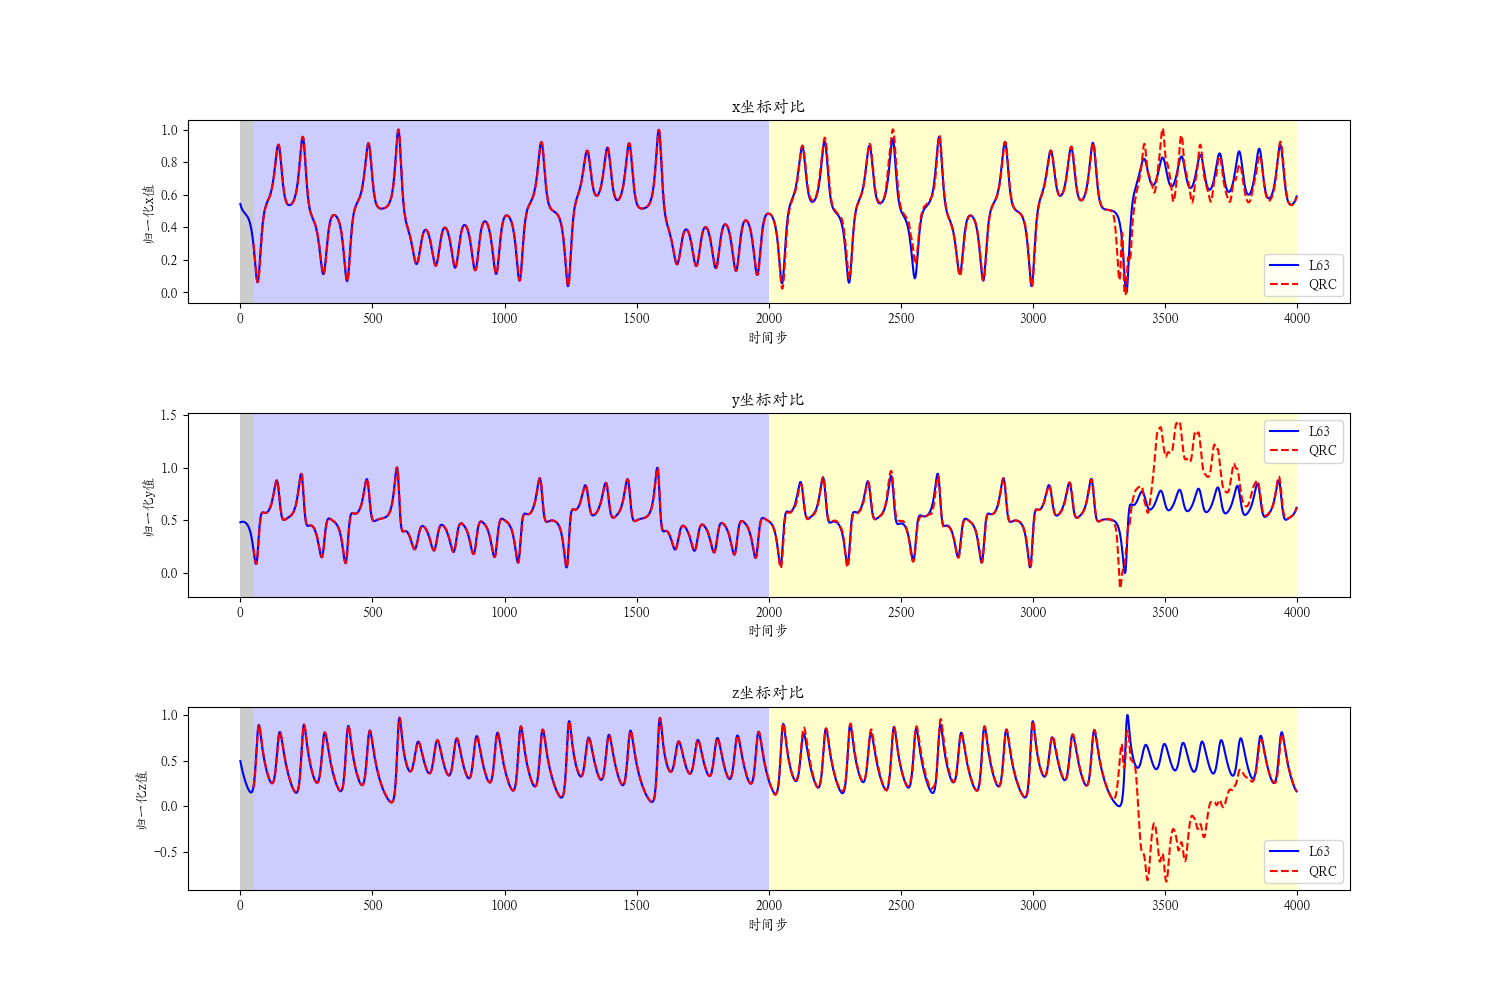

In [13]:
#主函数
if __name__ == "__main__":
    traj_normalized = lorenz63(x0 = np.array([1.508870, -1.531271, 25.46091]),
                               sigma=10.0,
                               rho=28.0,
                               beta=8/3,
                               num_steps=4000,
                               dt=0.01*0.9056) 
    quantum_outputs, n_qubits, n_cbits = all_probabilities(traj_normalized,varepsilon=0.05, n_qubits=9 , n_cbits=9, seed=42)

    ridge, washout, nstop_train = train_ridge_model(washout=50,
                                                    nstop_train=2000,
                                                    alpha=0,
                                                    loading_dataX=quantum_outputs,
                                                    loading_datay=traj_normalized)

    predictions = predict_next_state(method=ridge, loading_dataX=quantum_outputs, loading_datay=traj_normalized)

    print(predictions)
    mse = mean_squared_error(traj_normalized[nstop_train+1:], predictions[nstop_train:-1])#检查过，引用函数与文献一致
    print(f"测试集MSE: {mse}")
    #plot_normalized_traj(traj_normalized, title="Normalized Lorenz 63 Attractor")
    plot_comparison(dimensions=('x', 'y', 'z'), plot_3d=False, plot_washout = False)